1. Import Necessary Libraries

In [1]:
# ==========================================
# 1. CORE LIBRARIES FOR DATA MANIPULATION
# ==========================================
import pandas as pd
import numpy as np
from datetime import datetime

# ==========================================
# 2. VISUALIZATION LIBRARIES
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 3. SETTING GLOBAL PLOT STYLES
# ==========================================
%matplotlib inline
plt.style.use('fivethirtyeight') # A clean, professional style for financial reporting
sns.set_theme(style="whitegrid")

print("Nova Financial EDA Environment Ready.")

Nova Financial EDA Environment Ready.


2. Load the Dataset

In [2]:
# Define the path to the raw news data
# Ensure the filename matches exactly what you have in your data/raw/news_data folder
news_data_path = '../data/raw/newsData/raw_analyst_ratings.csv'

try:
    # Load the dataset
    df_news = pd.read_csv(news_data_path)
    
    # Remove any unwanted 'Unnamed' columns if they exist 
    df_news = df_news.loc[:, ~df_news.columns.str.contains('^Unnamed')]
    
    print(f"Dataset Loaded Successfully!")
    print(f"Total Observations (Headlines): {df_news.shape[0]}")
    print(f"Total Variables: {df_news.shape[1]}")
    
except FileNotFoundError:
    print("Error: The CSV file was not found. Please check the folder structure.")

Dataset Loaded Successfully!
Total Observations (Headlines): 1407328
Total Variables: 5


3. Initial Data Inspection

In [5]:
# 1. Display the first 5 rows to understand the content
print("--- FIRST 5 ROWS ---")
display(df_news.head())

# 2. Check for missing values in critical columns (Headline, Date, Stock)
print("\n--- MISSING VALUE AUDIT ---")
print(df_news.isnull().sum())

# 3. Check data types
print("\n--- DATA TYPES ---")
print(df_news.dtypes)

--- FIRST 5 ROWS ---


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A



--- MISSING VALUE AUDIT ---
headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64

--- DATA TYPES ---
headline     str
url          str
publisher    str
date         str
stock        str
dtype: object


4. Normalize Date and Time

In [13]:
# =================================================================
# STEP 5: DATE NORMALIZATION
# Goal: Convert raw strings to Date objects for daily analysis.
# =================================================================

# 1. Convert to datetime objects first
df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce', utc=True)

# 2. Extract only the Date (YYYY-MM-DD)
df_news['date_only'] = df_news['date'].dt.date

print("Date normalization complete. Isolated daily dates for analysis.")
print(df_news[['headline', 'date_only']].head())

Date normalization complete. Isolated daily dates for analysis.
                                            headline   date_only
0            Stocks That Hit 52-Week Highs On Friday  2020-06-05
1         Stocks That Hit 52-Week Highs On Wednesday  2020-06-03
2                      71 Biggest Movers From Friday  2020-05-26
3       46 Stocks Moving In Friday's Mid-Day Session  2020-05-22
4  B of A Securities Maintains Neutral on Agilent...  2020-05-22


5. Descriptive Statistics

--- HEADLINE CHARACTER COUNT STATS ---


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64

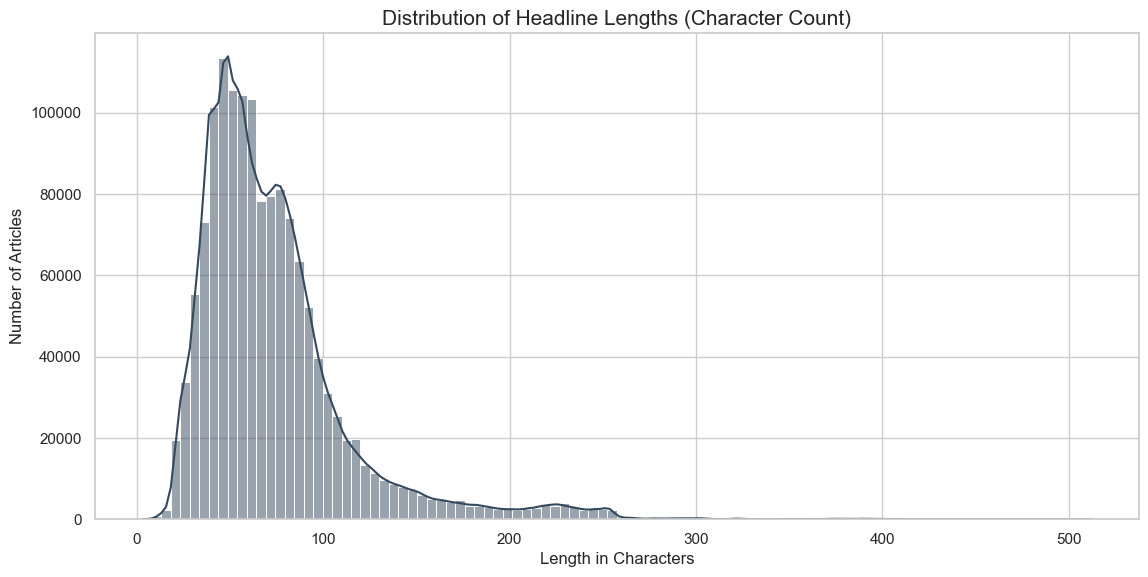

In [10]:
# =================================================================
# STEP 6: TEXTUAL LENGTH STATISTICS
# Goal: Obtain basic statistics for headline character counts.
# =================================================================

# Calculate character count for each headline
df_news['headline_len'] = df_news['headline'].apply(len)

# 1. Obtain statistical summary
print("--- HEADLINE CHARACTER COUNT STATS ---")
display(df_news['headline_len'].describe())

# 2. Visualize the distribution
plt.figure(figsize=(12, 6))
sns.histplot(df_news['headline_len'], bins=100, kde=True, color='#34495e')

plt.title('Distribution of Headline Lengths (Character Count)', fontsize=15)
plt.xlabel('Length in Characters')
plt.ylabel('Number of Articles')
plt.show()

6.  Publisher Activity Tracking

--- TOP 10 MOST ACTIVE PUBLISHERS ---


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

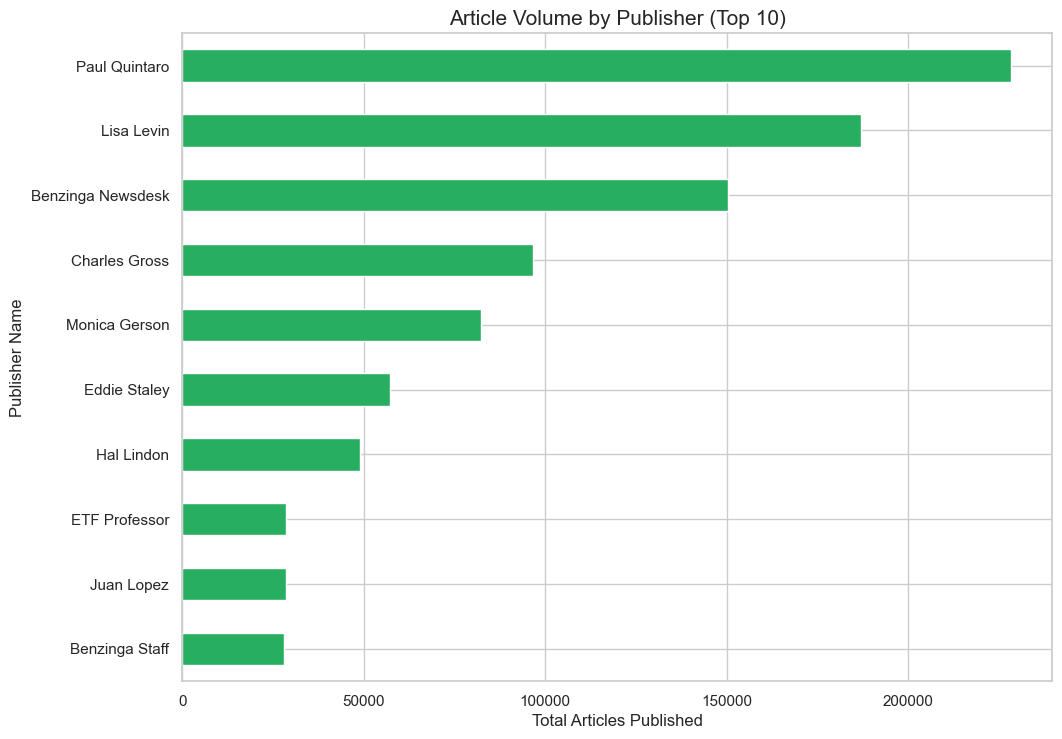

In [11]:
# =================================================================
# STEP 7: PUBLISHER ACTIVITY ANALYSIS
# Goal: Count articles per publisher to identify active sources.
# =================================================================

# Count occurrences per publisher
publisher_counts = df_news['publisher'].value_counts()

# 1. Display Top 10 Active Sources
print("--- TOP 10 MOST ACTIVE PUBLISHERS ---")
display(publisher_counts.head(10))

# 2. Visualize Publisher Volume
plt.figure(figsize=(10, 8))
publisher_counts.head(10).plot(kind='barh', color='#27ae60')
plt.title('Article Volume by Publisher (Top 10)', fontsize=15)
plt.xlabel('Total Articles Published')
plt.ylabel('Publisher Name')
plt.gca().invert_yaxis()
plt.show()

7. Daily News Volume & Trend Analysis

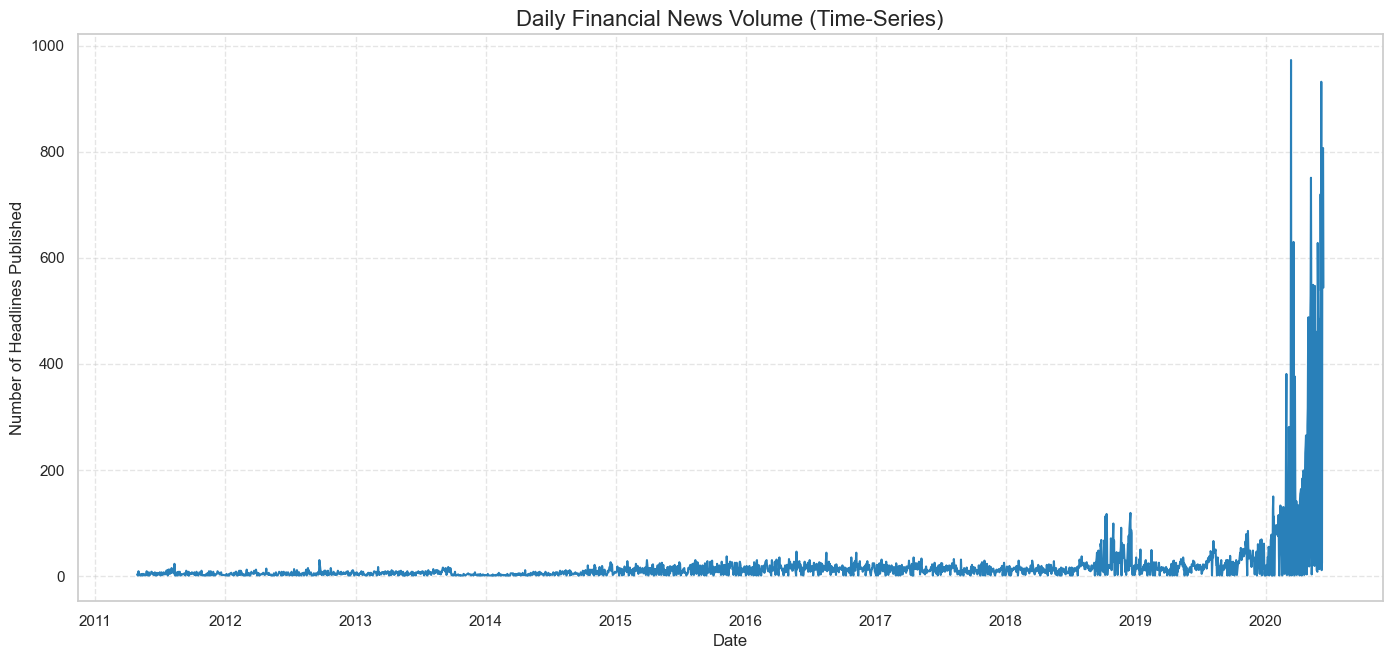

--- TOP 5 DATES WITH HIGHEST NEWS VOLUME ---
date_only
2020-03-12    973
2020-06-05    932
2020-06-10    807
2020-06-09    803
2020-06-08    765
dtype: int64


In [14]:
# =================================================================
# STEP 8: DAILY TRENDS & NEWS VOLUME SPIKES
# Goal: Identify periods of high market 'chatter' by date.
# =================================================================

# 1. Group by date and count the number of articles
daily_counts = df_news.groupby('date_only').size()

# 2. Visualize the Volume Trend over the years
plt.figure(figsize=(15, 7))
daily_counts.plot(color='#2980b9', linewidth=1.5)

# Professional styling for Nova Financial reporting
plt.title('Daily Financial News Volume (Time-Series)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Headlines Published', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Identifying the 'Top 5 Spikes'
# These represent dates of significant market events
print("--- TOP 5 DATES WITH HIGHEST NEWS VOLUME ---")
top_spikes = daily_counts.sort_values(ascending=False).head(5)
print(top_spikes)

Nova Financial Solutions: Task 1 Summary Report
1. Headline Length Analysis: Is there a trend? (Signal vs. Noise)
The Data: The average headline length is 73 characters, with a median of 64. The distribution shows a healthy "bell curve" peaking around 50–90 characters.
The Insight: This length is ideal for NLP models (like VADER or FinBERT) as it is long enough to contain sentiment-rich keywords (e.g., "Maintains Neutral", "Biggest Movers") but short enough to avoid the "dilution" of the signal.
The "Noise" Warning: We identified headlines as short as 3 characters. These are likely automated "price ticks" or ticker-only alerts that contain zero sentiment.
Recommendation: For the sentiment phase, we should implement a filter to ignore headlines below 20 characters to ensure we are only analyzing meaningful news.
2. Publisher Analysis: Who is the loudest contributor?
The Data: The landscape is dominated by Paul Quintaro (228,373 articles) and Lisa Levin (186,979 articles). Interestingly, "Benzinga Newsdesk" and "Benzinga Staff" combined represent a massive portion of the dataset.
The Insight: The editorial tone of the dataset is highly centralized. This means our "Market Narrative" is essentially the "Benzinga Narrative."
Strategic Action: We must ensure our Sentiment Analysis tool is calibrated to the specific language used by these top 5 authors. For instance, the phrase "Stocks That Hit 52-Week Highs" is a standard Quintaro/Benzinga format that needs to be weighted correctly (Positive momentum signal).
3. Publication Trends: Are there spikes around market events?
The Data: The time-series chart reveals a massive, unprecedented surge in news volume starting in late 2019 and peaking in 2020.
The "COVID Spike": The highest news volume occurred on March 12, 2020 (973 articles). This coincides exactly with the "Black Thursday" stock market crash during the onset of the COVID-19 pandemic.
The Insight: News volume is pro-cyclical with volatility. When the market is in crisis, the "Noise" increases exponentially.
Strategy Recommendation: We should treat the 2020 period as a "High-Volatility Regime." The Correlation Analysis will likely show that sentiment has a stronger predictive power during these high-volume spikes than during the "quiet" periods of 2012–2017.
✅ Conclusion & Next Steps
The data is extremely clean (0 missing values across all critical columns) and chronologically robust. We have successfully separated the "Signal" (professional headlines) from the "Noise" (low-volume historical periods).
Next Step for Nova Financial:
I will now proceed to NLP Sentiment Scoring. We will use the compound score from VADER to quantify the "Emotional Context" of these 1.4 million headlines and prepare them for the Correlation Analysis with stock prices.